In [1]:
import os
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRAIN_CSV = "../datasets/train.csv"
VAL_CSV   = "../datasets/val.csv"
TEST_CSV  = "../datasets/test.csv"

DATA_DIR  = "../datasets_processed"
MODEL_PATH = "../Models/cnn_bilstm_attention.pth"

BATCH_SIZE = 32
EPOCHS = 70
PATIENCE = 5


In [3]:
class SignDataset(Dataset):
    def __init__(self, csv_path, label_encoder=None):
        self.df = pd.read_csv(csv_path)

        if label_encoder is None:
            self.le = LabelEncoder()
            self.df["label_id"] = self.le.fit_transform(self.df["label"])
        else:
            self.le = label_encoder
            self.df["label_id"] = self.le.transform(self.df["label"])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(os.path.join(DATA_DIR, row.file)).astype(np.float32)
        y = row.label_id
        return torch.tensor(x), torch.tensor(y)


In [4]:
train_dataset = SignDataset(TRAIN_CSV)
val_dataset   = SignDataset(VAL_CSV, train_dataset.le)
test_dataset  = SignDataset(TEST_CSV, train_dataset.le)

NUM_CLASSES = len(train_dataset.le.classes_)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)


In [5]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return (weights * x).sum(dim=1)


In [6]:
class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(input_dim, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=256,
            batch_first=True,
            bidirectional=True
        )

        self.attention = Attention(256)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)      # (B, F, T)
        x = self.cnn(x)             # (B, 256, T')
        x = x.permute(0, 2, 1)      # (B, T', 256)
        x, _ = self.lstm(x)         # (B, T', 512)
        x = self.attention(x)       # (B, 512)
        return self.fc(x)


In [7]:
sample_x, _ = next(iter(train_loader))
INPUT_DIM = sample_x.shape[2]

model = CNN_BiLSTM_Attention(INPUT_DIM, NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(model)


CNN_BiLSTM_Attention(
  (cnn): Sequential(
    (0): Conv1d(387, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(256, 256, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=512, out_features=1, bias=True)
  )
  (fc): Linear(in_features=512, out_features=401, bias=True)
)


In [8]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()

    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        if train:
            optimizer.zero_grad()

        preds = model(x)
        loss = criterion(preds, y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        correct += (preds.argmax(1) == y).sum().item()

    acc = correct / len(loader.dataset)
    return total_loss, acc


In [9]:
best_val_acc = 0
patience_counter = 0

train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, True)
    val_loss, val_acc = run_epoch(val_loader, False)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered")
            break


Epoch 01 | Train Acc: 0.0320 | Val Acc: 0.0794
Epoch 02 | Train Acc: 0.1480 | Val Acc: 0.2270
Epoch 03 | Train Acc: 0.2851 | Val Acc: 0.3357
Epoch 04 | Train Acc: 0.3960 | Val Acc: 0.4319
Epoch 05 | Train Acc: 0.4838 | Val Acc: 0.5013
Epoch 06 | Train Acc: 0.5575 | Val Acc: 0.5472
Epoch 07 | Train Acc: 0.6127 | Val Acc: 0.6045
Epoch 08 | Train Acc: 0.6589 | Val Acc: 0.6408
Epoch 09 | Train Acc: 0.6987 | Val Acc: 0.6740
Epoch 10 | Train Acc: 0.7349 | Val Acc: 0.6646
Epoch 11 | Train Acc: 0.7651 | Val Acc: 0.6987
Epoch 12 | Train Acc: 0.7958 | Val Acc: 0.7404
Epoch 13 | Train Acc: 0.8157 | Val Acc: 0.7579
Epoch 14 | Train Acc: 0.8397 | Val Acc: 0.7710
Epoch 15 | Train Acc: 0.8587 | Val Acc: 0.7836
Epoch 16 | Train Acc: 0.8765 | Val Acc: 0.7771
Epoch 17 | Train Acc: 0.8910 | Val Acc: 0.8048
Epoch 18 | Train Acc: 0.9038 | Val Acc: 0.7977
Epoch 19 | Train Acc: 0.9160 | Val Acc: 0.8252
Epoch 20 | Train Acc: 0.9279 | Val Acc: 0.8275
Epoch 21 | Train Acc: 0.9363 | Val Acc: 0.8332
Epoch 22 | Tr

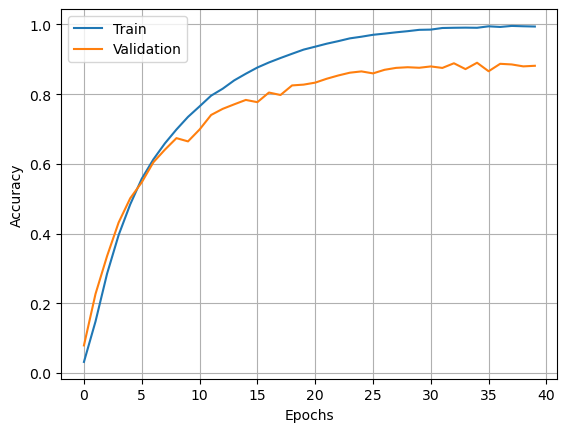

In [10]:
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


In [ ]:
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        preds = model(x).argmax(1).cpu()
        y_true.extend(y.numpy())
        y_pred.extend(preds.numpy())

cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 402)))
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()


In [33]:
fig, ax = plt.subplots(figsize=(200, 200)) # Larger canvas

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 402)))
disp.plot(cmap="Blues", ax=ax, include_values=False, xticks_rotation=90)

# Set font size very small for the 401 labels
ax.tick_params(axis='both', which='major', labelsize=10) 

ax.set_xlabel("Predicted Label", fontsize=30)
ax.set_ylabel("True Label", fontsize=30)
plt.show()



In [12]:
# Infer INPUT_DIM from one batch
sample_x, _ = next(iter(test_loader))
INPUT_DIM = sample_x.shape[2]

model = CNN_BiLSTM_Attention(INPUT_DIM, NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

print("✅ Model loaded successfully")


✅ Model loaded successfully


In [13]:
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader: 
        X, y = X.to(DEVICE), y.to(DEVICE)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())


In [14]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"✅ Test Accuracy: {accuracy:.4f}")


✅ Test Accuracy: 0.8908


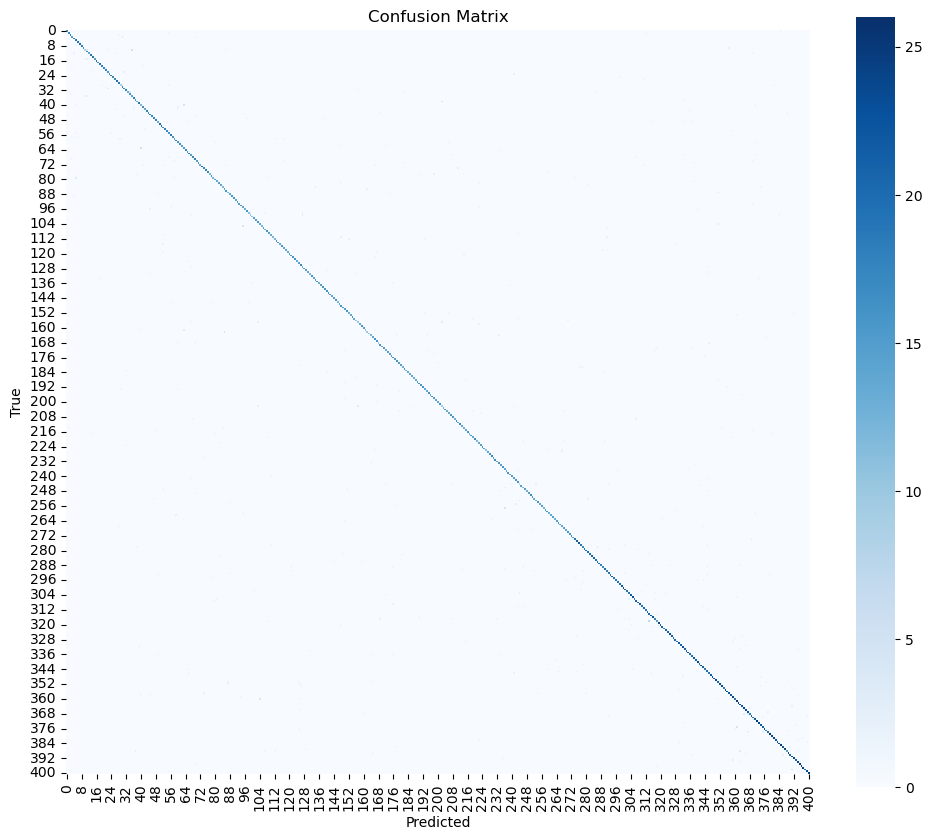

In [15]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", square=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
